In [1]:
!pip install pyspark


In [4]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Distributed Fraud Detection") \
    .getOrCreate()

print("Spark Started")

Spark Started


In [6]:
df = spark.read.csv("creditcard.csv", header=True, inferSchema=True)

df.show(5)
df.printSchema()

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|                V22|     

In [7]:
df.groupBy("Class").count().show()

+-----+------+
|Class| count|
+-----+------+
|    1|   492|
|    0|284315|
+-----+------+



In [8]:
fraud = df.filter(df.Class == 1)
normal = df.filter(df.Class == 0)

# Downsample normal transactions
normal_sample = normal.sample(fraction=0.1)

balanced_df = normal_sample.union(fraud)

balanced_df.groupBy("Class").count().show()

+-----+-----+
|Class|count|
+-----+-----+
|    0|28772|
|    1|  492|
+-----+-----+



In [9]:
from pyspark.ml.feature import VectorAssembler

feature_columns = df.columns[:-1]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(balanced_df)

data = data.select("features", "Class")

data.show(5)

+--------------------+-----+
|            features|Class|
+--------------------+-----+
|[10.0,0.384978215...|    0|
|[12.0,-0.75241704...|    0|
|[14.0,-5.40125766...|    0|
|[23.0,1.322707269...|    0|
|[26.0,-0.52991228...|    0|
+--------------------+-----+
only showing top 5 rows


In [11]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

In [12]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    labelCol="Class",
    featuresCol="features"
)

model = lr.fit(train_data)

In [13]:
predictions = model.transform(test_data)

predictions.select("Class", "prediction", "probability").show(10)

+-----+----------+--------------------+
|Class|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.98978460455810...|
|    0|       0.0|[0.99859702790198...|
|    0|       0.0|[0.99883299291894...|
|    0|       0.0|[0.98392719436329...|
|    0|       0.0|[0.99888701985242...|
|    0|       0.0|[0.98484287299105...|
|    0|       0.0|[0.99608749243968...|
|    0|       0.0|[0.99849954319884...|
|    0|       0.0|[0.99835548289386...|
|    0|       0.0|[0.99731410595750...|
+-----+----------+--------------------+
only showing top 10 rows


In [14]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="Class")

accuracy = evaluator.evaluate(predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9910887579364109


In [15]:
predictions.groupBy("Class", "prediction").count().show()

+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0| 5639|
|    0|       1.0|    3|
|    1|       0.0|   16|
|    1|       1.0|   85|
+-----+----------+-----+



In [16]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="Class",
    featuresCol="features",
    numTrees=50
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

rf_accuracy = evaluator.evaluate(rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9779693318498817


In [17]:
import pandas as pd

pdf = pd.read_csv("creditcard.csv")

print("Pandas shape:", pdf.shape)

Pandas shape: (284807, 31)


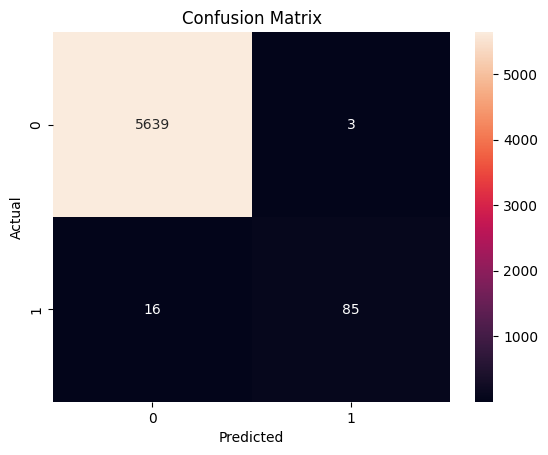

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Convert to pandas
pdf = predictions.select("Class", "prediction").toPandas()

# Confusion matrix
cm = confusion_matrix(pdf["Class"], pdf["prediction"])

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

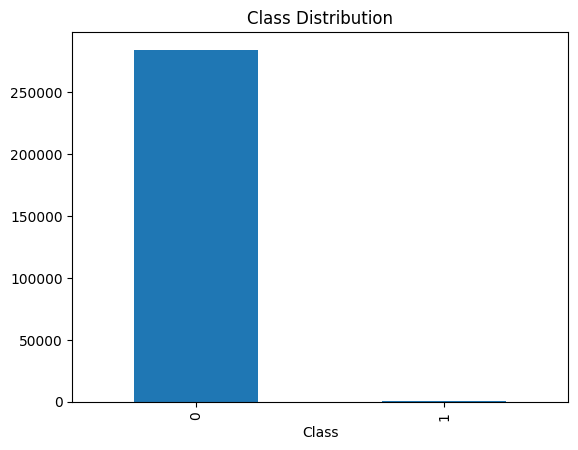

In [19]:
pdf = df.select("Class").toPandas()

plt.figure()
pdf["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

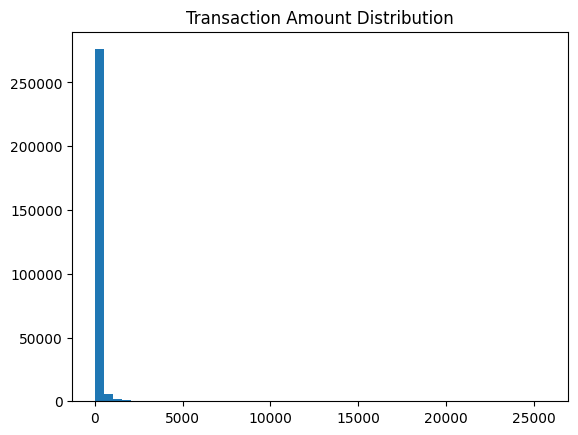

In [20]:
pdf = df.select("Amount").toPandas()

plt.figure()
plt.hist(pdf["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pdf = predictions.select("Class", "prediction").toPandas()

print("Accuracy:", accuracy_score(pdf["Class"], pdf["prediction"]))
print("Precision:", precision_score(pdf["Class"], pdf["prediction"]))
print("Recall:", recall_score(pdf["Class"], pdf["prediction"]))
print("F1 Score:", f1_score(pdf["Class"], pdf["prediction"]))

Accuracy: 0.9966916245864531
Precision: 0.9659090909090909
Recall: 0.8415841584158416
F1 Score: 0.8994708994708994
